In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import matplotlib.ticker as ticker
from statsmodels.stats.multitest import multipletests
import os

In [2]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

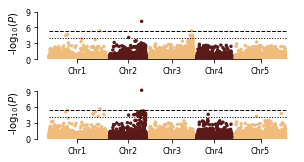

In [4]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)



def plotting(dataframe,idx):
    sns.scatterplot(x='position',
                    y='P',
                    data=dataframe,
                    hue='chr',
                    palette=['#F1BB7A','#5B1A18','#F1BB7A','#5B1A18','#F1BB7A'],
                    marker='o',
                    s=12,
                    linewidth=0,
                    legend=False,
                    ax=ax[idx])
    ax[idx].set_xticks([chr1,chr2,chr3,chr4,chr5]),
    ax[idx].tick_params(axis='both', which='major', labelsize=8)
    ax[idx].set_xticklabels(["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
#     ax[idx].set_title('w. Chr5:' + str(position))
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
    ax[idx].hlines(y=-np.log10(0.05/len(dataframe)),
                 xmin=min(dataframe['position']),
                 xmax=max(dataframe['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
                 zorder=1)
    ax[idx].hlines(y=classic[classic["Significant"] == True]['P'].min(),
                 xmin=min(classic['position']),
                 xmax=max(classic['position']),
                 color='0',
                 linestyle=':',
                 linewidth=1,
    #              alpha=0.4,
                 zorder=1)
    ax[idx].yaxis.set_major_locator(ticker.MultipleLocator(3))
    ax[idx].set_ylim(0,10)
    
    
classic=parse('FO_leaf_B_blues.assoc.txt.gz')
covariate=parse('FO_leaf_B_blues_chr3_22436584_cov.assoc.txt.gz')

rejected, pvals_corrected, _, _ = multipletests(classic['p_lrt'], alpha=0.1, method='fdr_bh')
classic["Significant"] = rejected
classic["FDR_corrected_pval"] = pvals_corrected

cm = 1/2.54
fig , ax = plt.subplots(2,1,figsize=(11*cm,6*cm))
plotting(classic,0)
# ax[0].set_title('all SNPs')
plotting(covariate,1)
# ax[1].set_title('w. $\itBOR2$_S313G')

# ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# plt.xlabel('Chromosome',fontsize=10)
# plt.ylim(0,20)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
# plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig("FigS2a.png", format="png",bbox_inches="tight",facecolor="w",dpi=600)

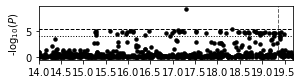

In [30]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)


start = 14000000
end = 19698289
def zooming(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df.loc[(df['chr'] == 2) &
                (df['ps'] > start) &
                (df['ps'] < end)])

full=parse('FO_leaf_B_blues.assoc.txt.gz')
classic=zooming('FO_leaf_B_blues.assoc.txt.gz')
covariate=zooming('FO_leaf_B_blues_chr3_22436584_cov.assoc.txt.gz')

rejected, pvals_corrected, _, _ = multipletests(full['p_lrt'], alpha=0.1, method='fdr_bh')
full["Significant"] = rejected
full["FDR_corrected_pval"] = pvals_corrected

# Chr2_19374681_ld=pd.read_table('chr2_19374681_ld.ld', sep = '\s+')
# Chr2_19374681_ld.head()
#Combine LD info and zoom
# zoom=pd.merge(classic,Chr2_19374681_ld,left_on='ps',right_on='BP_B')
# zoom.head()

#Import color information
colors = plt.cm.magma(np.linspace(0,1,5))

def major_formatter(x, pos):
    y = x /1000000
    return "%.1f" % y

from matplotlib.gridspec import GridSpec

cm = 1/2.54
fig = plt.figure(figsize=(14*cm,5*cm))
# fig = plt.figure(figsize=(10,10))
gs = GridSpec(4, 6, figure=fig, hspace=0)
ax1 = fig.add_subplot(gs[:2,:5])
ax1=sns.scatterplot(x='ps',
                y='P',
                data=covariate,
                marker='o',
                color='0',
                s=15,
                linewidth=0.5,
                edgecolor='0',
                legend=False,
                zorder=2)
# y_SNP = zoom.loc[zoom['ps'] == 19374681,'P'].values
# ax1.plot(19374681,y_SNP,'D',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
ax1.hlines(y=-np.log10(0.05/len(full)),
             xmin=min(full['position']),
             xmax=max(full['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax1.hlines(y=full[full["Significant"] == True]['P'].min(),
             xmin=min(full['position']),
             xmax=max(full['position']),
             color='0',
             linestyle=':',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax1.set_xlim(start,end)
# ax1.set_ylim(-2,12)
ax1.set_xlabel('')
ax1.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5))
# ax1.set_xticklabels([])
# ax1.annotate('chr2:19374681',xy=(19374681-550000,y_SNP+3),xytext=(19374681-550000,y_SNP+3),fontsize=8)
# ax1.axes.get_xaxis().set_visible(False)
ax1.xaxis.set_major_formatter(major_formatter)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(500000))
# ax1.spines["bottom"].set_visible(False) 
ax1.axvline(x=19357420,linewidth=1,color='0',alpha=0.6,linestyle='--') #BOR1



# ax2 = fig.add_subplot(gs[2:4,:5])
# ax2=sns.scatterplot(x='ps',
#                 y='P',
#                 data=covariate,
#                 color='k',
#                 s=15,
#                 linewidth=1,
#                 edgecolor='k',
#                 legend=False,
#                 zorder=2)
# ax2.hlines(y=-np.log10(0.05/len(full)),
#              xmin=min(full['position']),
#              xmax=max(full['position']),
#              color='0',
#              linestyle='--',
#              linewidth=1,
# #              alpha=0.4,
#              zorder=1)
# ax2.hlines(y=full[full["Significant"] == True]['P'].min(),
#              xmin=min(full['position']),
#              xmax=max(full['position']),
#              color='0',
#              linestyle=':',
#              linewidth=1,
# #              alpha=0.4,
#              zorder=1)
# ax2.set_xlim(start,end)
# ax2.set_ylim(-2,12)
# ax2.set_xlabel('')
# ax2.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
# ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
# ax2.xaxis.set_major_formatter(major_formatter)
# ax2.xaxis.set_major_locator(ticker.MultipleLocator(400000))
# ax2.axvline(x=19357420,linewidth=1,color='0',alpha=0.6,linestyle='--') #BOR1

# # ax2.set_yticklabels([])
# ax2.set_xlabel('Position in Mb',fontsize=10)

# Add legend
# norm = plt.Normalize(zoom['R2'].min(), zoom['R2'].max())
# sm = plt.cm.ScalarMappable(norm=norm,cmap='magma')
# sm.set_array([])
# ax3 = fig.add_subplot(gs[0:4,5])
# ax3.axis('off')
# ax3.get_legend().remove()
# axins = inset_axes(ax3,
#                     width="15%",  
#                     height="100%",
#                     loc='center',
#                     borderpad=-5
#                    )
# ax3.figure.colorbar(sm,pad=0.05,shrink=0.8,cax=axins,orientation="vertical")
plt.tight_layout
# plt.savefig("Fig2b.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig2b.svg", format="svg")
plt.savefig("ZoomBOR1_afterBOR2cov.png", format="png",bbox_inches="tight",facecolor="w")

## 